In [2]:
# %% Cell 1 — Setup
# Standard notebook setup: imports, autoreload, pandas display options.
# Autoreload means edits to src/ files take effect without restarting
# the kernel — huge productivity win during iterative development.
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# Add project root to path so we can `from src... import ...`
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from config import PROFILES, PROFILE_LABELS, PROFILE_COLORS
from src.utils.db import db_session, table_row_counts
from src.analysis.trackers import (
    tracker_prevalence_by_profile,
    tracker_frequency_table,
    jaccard_similarity_matrix,
    differential_trackers,
)

# Pandas display tweaks — show more columns/rows by default.
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. Table row counts

The first sanity check: every (table × profile) cell should be
nonzero, and counts should be of similar orders of magnitude
across profiles for the same table.

In [3]:
# %% Cell 2
counts = table_row_counts()
counts_df = pd.DataFrame([
    {'table.profile': k, 'rows': v}
    for k, v in counts.items()
])
counts_df


,table.profile,rows
0,site_visits.control,100
1,site_visits.pop_culture,100
2,site_visits.gaming,100
3,site_visits.fitness,100
4,site_visits.finance,100
5,http_requests.pop_culture,33546
6,http_requests.control,48574
7,http_requests.finance,32705
8,http_requests.gaming,35234
9,http_requests.fitness,31245


**What to look for:**
  - Any zero counts → that profile's crawl failed for that table
  - Wildly different counts → one profile crawled fewer pages
  - Missing tables → check load_sqlite.py warnings

## 2. Visits per profile

This is the denominator for almost every per-visit metric, so
we need it to be roughly equal across profiles. Large imbalances
require either re-running short profiles or weighting comparisons.

In [ ]:
with db_session(read_only=True) as con:
    visits = con.execute("""
        SELECT
            profile,
            COUNT(*)                      AS n_visits,
            COUNT(DISTINCT site_url)      AS n_unique_sites,
            MIN(visit_id)                 AS min_visit_id,
            MAX(visit_id)                 AS max_visit_id
        FROM site_visits
        GROUP BY profile
        ORDER BY profile
    """).df()
visits

,profile,n_visits,n_unique_sites,min_visit_id,max_visit_id
0,control,100,100,42780216991248,8871953758635331
1,finance,100,100,1399925820993,8988456897356141
2,fitness,100,100,152428241379277,8985726066369030
3,gaming,100,100,102831053174655,8951863300858986
4,pop_culture,100,100,111534140620075,8895005896071519


**Action item:** if `n_visits` differs by more than ~10% across
profiles, decide now whether to re-crawl or document the imbalance
in your methodology section.

## 3. Distribution of requests per page
A histogram of "how many HTTP requests did each page make?"
Should be heavy-tailed (most pages: tens of requests; some pages:
hundreds). Compare distributions across profiles — different
means/shapes here are early evidence of behavioral targeting.

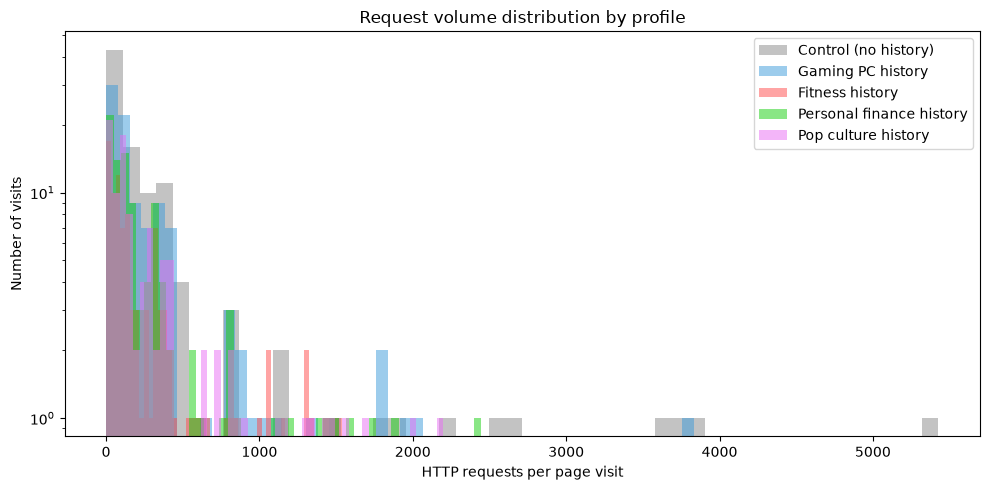

,count,mean,std,min,25%,50%,75%,max
profile,,,,,,,,
control,100.0,485.74,927.231903,1.0,67.75,150.0,373.75,5427.0
finance,100.0,327.05,466.300189,1.0,58.75,142.5,326.25,2447.0
fitness,100.0,312.45,395.652290,1.0,58.00,139.5,374.25,1537.0
gaming,100.0,352.34,560.171911,1.0,62.00,146.0,359.75,3832.0
pop_culture,100.0,335.46,459.049268,1.0,59.00,139.5,368.75,2199.0


In [ ]:
# %% Cell 4
with db_session(read_only=True) as con:
    reqs_per_visit = con.execute("""
        SELECT profile, visit_id, COUNT(*) AS n_requests
        FROM http_requests
        GROUP BY profile, visit_id
    """).df()

fig, ax = plt.subplots(figsize=(10, 5))
for profile in PROFILES:
    data = reqs_per_visit[reqs_per_visit['profile'] == profile]['n_requests']
    ax.hist(
        data,
        bins=50,
        alpha=0.5,
        label=PROFILE_LABELS[profile],
        color=PROFILE_COLORS[profile],
    )
ax.set_xlabel('HTTP requests per page visit')
ax.set_ylabel('Number of visits')
ax.set_title('Request volume distribution by profile')
ax.legend()
ax.set_yscale('log')   # log scale handles the heavy tail nicely
plt.tight_layout()
plt.show()

# Numerical summary alongside the plot
reqs_per_visit.groupby('profile')['n_requests'].describe()

## 4. Unique tracker hosts per profile (THE headline metric)

This is the first answer to your research question:
"Does seeded history change tracking?"

In [12]:
# %% Cell 5
prevalence = tracker_prevalence_by_profile()
prevalence

,profile,n_visits,n_unique_domains,n_unique_subsidiaries,n_unique_parents,domains_per_visit,subsidiaries_per_visit,parents_per_visit
0,control,100,947,718,718,9.47,7.18,7.18
1,finance,100,891,687,687,8.91,6.87,6.87
2,fitness,100,900,690,691,9.00,6.90,6.91
3,gaming,100,891,672,671,8.91,6.72,6.71
4,pop_culture,100,945,726,725,9.45,7.26,7.25


KeyError: 'n_unique_etld1'

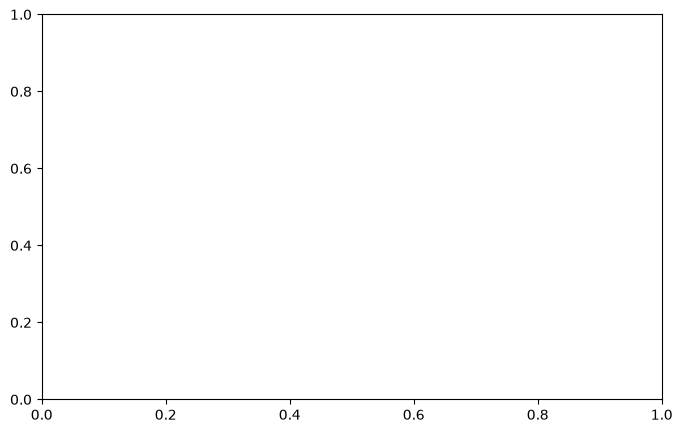

In [13]:
# %% Cell 6
# Bar chart of unique hosts per profile — the "money shot" for a
# first-pass result. If this isn't differentiating profiles, you
# may need to re-examine your seeding methodology.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    prevalence['profile'],
    prevalence['n_unique_etld1'],
    color=[PROFILE_COLORS[p] for p in prevalence['profile']],
)
ax.set_xlabel('Profile')
ax.set_ylabel('Unique third-party eTLD+1s contacted')
ax.set_title('Tracking breadth by seeded history profile')
for i, v in enumerate(prevalence['n_unique_etld1']):
    ax.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()


## 5. Jaccard similarity heatmap

How similar are the tracker landscapes between profile pairs?
Values near 1.0 = nearly identical sets; values near 0.0 = highly
divergent. The diagonal will always be 1.0

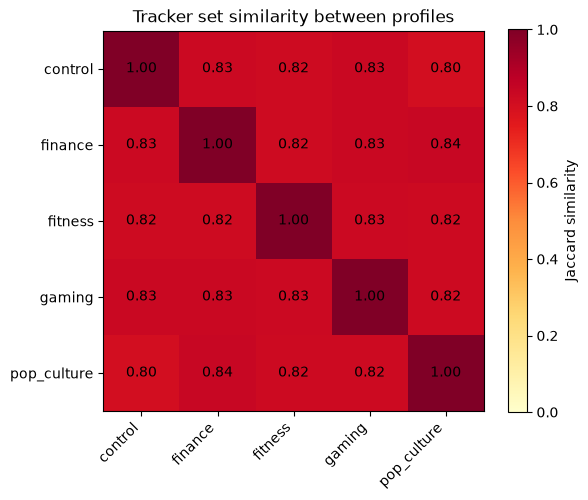

,control,finance,fitness,gaming,pop_culture
control,1.000,0.826,0.818,0.834,0.803
finance,0.826,1.000,0.819,0.833,0.839
fitness,0.818,0.819,1.000,0.826,0.823
gaming,0.834,0.833,0.826,1.000,0.823
pop_culture,0.803,0.839,0.823,0.823,1.000


In [9]:
# %% Cell 7
jaccard = jaccard_similarity_matrix()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jaccard.values, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(jaccard.columns)))
ax.set_yticks(range(len(jaccard.index)))
ax.set_xticklabels(jaccard.columns, rotation=45, ha='right')
ax.set_yticklabels(jaccard.index)
# Annotate each cell with its value
for i in range(len(jaccard.index)):
    for j in range(len(jaccard.columns)):
        ax.text(j, i, f"{jaccard.iloc[i, j]:.2f}",
                ha='center', va='center', color='black')
plt.colorbar(im, ax=ax, label='Jaccard similarity')
ax.set_title('Tracker set similarity between profiles')
plt.tight_layout()
plt.show()

jaccard.round(3)


**Interpretation guide:**
  - All values > 0.9 → profiles are too similar; either your
    seeding isn't taking effect, or trackers aren't reacting yet
  - Values 0.5–0.8 → healthy signal; most trackers are universal
    but a meaningful minority differ by profile
  - Values < 0.3 → very strong profile-specific tracking

## 6. Differential trackers (seeded vs. control)

For each non-control profile, list the top 15 trackers with the
highest lift relative to the control profile. These are the
strongest candidates for behavioral targeting evidence.

In [10]:
# %% Cell 8
for profile in PROFILES:
    if profile == 'control':
        continue
    print(f"\n{'='*60}")
    print(f"Top 15 differential trackers: {profile} vs control")
    print('='*60)
    diff = differential_trackers(profile, 'control').head(15)
    print(diff.to_string(index=False))


Top 15 differential trackers: gaming vs control
                etld1  visits_a  visits_b  delta  lift
mediagotechnology.com       5.0       0.0    5.0 6.000
         createjs.com       4.0       0.0    4.0 5.000
         narrative.io       3.0       0.0    3.0 4.000
       pro-market.net       6.0       1.0    5.0 3.500
           amazon.dev       5.0       1.0    4.0 3.000
            clinch.co       6.0       2.0    4.0 2.333
           truste.com       7.0       3.0    4.0 2.000
              a2z.com       3.0       1.0    2.0 2.000
          datadome.co       3.0       1.0    2.0 2.000
         trustarc.com      10.0       5.0    5.0 1.833
 googleadservices.com       4.0       2.0    2.0 1.667
ssl-images-amazon.com       4.0       2.0    2.0 1.667
     media-amazon.com       4.0       2.0    2.0 1.667
    ads-tinyorbit.com       7.0       4.0    3.0 1.600
         ftstatic.com       7.0       4.0    3.0 1.600

Top 15 differential trackers: fitness vs control
               etld1 

## 7. Ad ingestion sanity check (if ads.parquet exists)

In [11]:
# %% Cell 9
try:
    with db_session(read_only=True) as con:
        ad_summary = con.execute("""
            SELECT
                profile,
                COUNT(*)                              AS n_ads,
                COUNT(DISTINCT advertiser_network)    AS n_networks,
                AVG(ocr_char_count)                   AS avg_ocr_chars,
                SUM(CASE WHEN has_screenshot THEN 1 ELSE 0 END)
                                                      AS n_with_screenshot
            FROM ads
            GROUP BY profile
            ORDER BY profile
        """).df()
    print(ad_summary.to_string(index=False))
except Exception as e:
    print(f"Ad data not available yet: {e}")

    profile  n_ads  n_networks  avg_ocr_chars  n_with_screenshot
    control    197           6            0.0              153.0
    finance    185           5            0.0              144.0
    fitness    167           5            0.0              132.0
     gaming    205           5            0.0              161.0
pop_culture    215           6            0.0              144.0


## Findings checklist

Before moving on to notebook 02, confirm:
  - [ ] Row counts look balanced across profiles
  - [ ] Visit counts within ~10% of each other
  - [ ] Request distributions show some differentiation
  - [ ] Tracker prevalence varies across profiles
  - [ ] Jaccard values are in the 0.5–0.8 range
  - [ ] Differential trackers list contains plausible advertisers
        (Criteo, AppNexus, etc. — not random domains)

If anything's off, fix at the data level before doing statistics.